### Step 1 — Import Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


### Step 2 — Load Race Data

In [4]:
df = pd.read_csv(
    "../../Dataset/f1_final_cleaned_data.csv"
)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (7109, 28)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,podium,driver_name,constructor_name,round,race_name,circuitId,date,circuit_name,location,country,qualifying_position
0,20323,337,4,6,8,3.0,1.0,1,1,25.0,49,45.0,1.0,1:58.287,191.706,1,2010,1,Fernando Alonso,Ferrari,1,Bahrain Grand Prix,3,2010-03-14,Bahrain International Circuit,Sakhir,Bahrain,3.0
1,20324,337,13,6,7,2.0,2.0,2,2,18.0,49,38.0,5.0,1:59.732,189.392,1,2010,1,Felipe Massa,Ferrari,1,Bahrain Grand Prix,3,2010-03-14,Bahrain International Circuit,Sakhir,Bahrain,2.0
2,20325,337,1,1,2,4.0,3.0,3,3,15.0,49,42.0,4.0,1:59.560,189.665,1,2010,1,Lewis Hamilton,McLaren,1,Bahrain Grand Prix,3,2010-03-14,Bahrain International Circuit,Sakhir,Bahrain,4.0
3,20326,337,20,9,5,1.0,4.0,4,4,12.0,49,32.0,12.0,2:00.218,188.627,1,2010,0,Sebastian Vettel,Red Bull,1,Bahrain Grand Prix,3,2010-03-14,Bahrain International Circuit,Sakhir,Bahrain,1.0
4,20327,337,3,131,4,5.0,5.0,5,5,10.0,49,45.0,13.0,2:00.236,188.599,1,2010,0,Nico Rosberg,Mercedes,1,Bahrain Grand Prix,3,2010-03-14,Bahrain International Circuit,Sakhir,Bahrain,5.0


### Step 3 — Check Available Columns

In [5]:
df.columns.tolist()

['resultId',
 'raceId',
 'driverId',
 'constructorId',
 'number',
 'grid',
 'position',
 'positionText',
 'positionOrder',
 'points',
 'laps',
 'fastestLap',
 'rank',
 'fastestLapTime',
 'fastestLapSpeed',
 'statusId',
 'year',
 'podium',
 'driver_name',
 'constructor_name',
 'round',
 'race_name',
 'circuitId',
 'date',
 'circuit_name',
 'location',
 'country',
 'qualifying_position']

### Step 4 — Analyze Pit Stop Data Availability

In [6]:
pit_columns = [
    col for col in df.columns
    if "pit" in col.lower()
]

pit_columns

[]

### Step 5 — Create Race Strategy Dataset

In [7]:
strategy_df = df[
    [
        "year",
        "round",
        "driverId",
        "constructorId",
        "circuitId",
        "laps",
        "points",
        "positionOrder",
        "podium"
    ]
].copy()


strategy_df.head()

,year,round,driverId,constructorId,circuitId,laps,points,positionOrder,podium
0,2010,1,4,6,3,49,25.0,1,1
1,2010,1,13,6,3,49,18.0,2,1
2,2010,1,1,1,3,49,15.0,3,1
3,2010,1,20,9,3,49,12.0,4,0
4,2010,1,3,131,3,49,10.0,5,0


### Step 6 — Create Race Performance Feature

In [8]:
strategy_df["race_performance"] = (
    strategy_df["points"] /
    strategy_df["laps"]
)

strategy_df.head()

,year,round,driverId,constructorId,circuitId,laps,points,positionOrder,podium,race_performance
0,2010,1,4,6,3,49,25.0,1,1,0.510204
1,2010,1,13,6,3,49,18.0,2,1,0.367347
2,2010,1,1,1,3,49,15.0,3,1,0.306122
3,2010,1,20,9,3,49,12.0,4,0,0.244898
4,2010,1,3,131,3,49,10.0,5,0,0.204082


### Step 7 — Create Finishing Efficiency Feature

In [9]:
strategy_df["finishing_efficiency"] = (
    1 /
    strategy_df["positionOrder"]
)

strategy_df.head()

,year,round,driverId,constructorId,circuitId,laps,points,positionOrder,podium,race_performance,finishing_efficiency
0,2010,1,4,6,3,49,25.0,1,1,0.510204,1.000000
1,2010,1,13,6,3,49,18.0,2,1,0.367347,0.500000
2,2010,1,1,1,3,49,15.0,3,1,0.306122,0.333333
3,2010,1,20,9,3,49,12.0,4,0,0.244898,0.250000
4,2010,1,3,131,3,49,10.0,5,0,0.204082,0.200000


### Step 8 — Analyze Constructor Strategy Performance

In [10]:
constructor_strategy = (
    strategy_df
    .groupby("constructorId")
    [
        [
            "race_performance",
            "finishing_efficiency"
        ]
    ]
    .mean()
    .sort_values(
        "race_performance",
        ascending=False
    )
)

constructor_strategy.head(10)

,race_performance,finishing_efficiency
constructorId,,
131,0.224015,0.382659
9,0.222931,0.365554
6,0.177914,0.268329
1,0.122185,0.209966
208,0.083821,0.154110
211,0.062400,0.133499
117,0.060529,0.105798
213,0.056928,0.100250
10,0.055822,0.112001


### Step 9 — Analyze Driver Strategy Performance

In [11]:
driver_strategy = (
    strategy_df
    .groupby("driverId")
    [
        [
            "race_performance",
            "finishing_efficiency"
        ]
    ]
    .mean()
    .sort_values(
        "race_performance",
        ascending=False
    )
)

driver_strategy.head(10)

,race_performance,finishing_efficiency
driverId,,
830,0.296200,0.462939
1,0.271634,0.462548
20,0.219603,0.370501
3,0.194535,0.356132
17,0.192801,0.317539
844,0.179988,0.251738
857,0.175507,0.299653
847,0.169160,0.198732
863,0.166150,0.318980


### Step 10 — Plot Constructor Strategy Performance

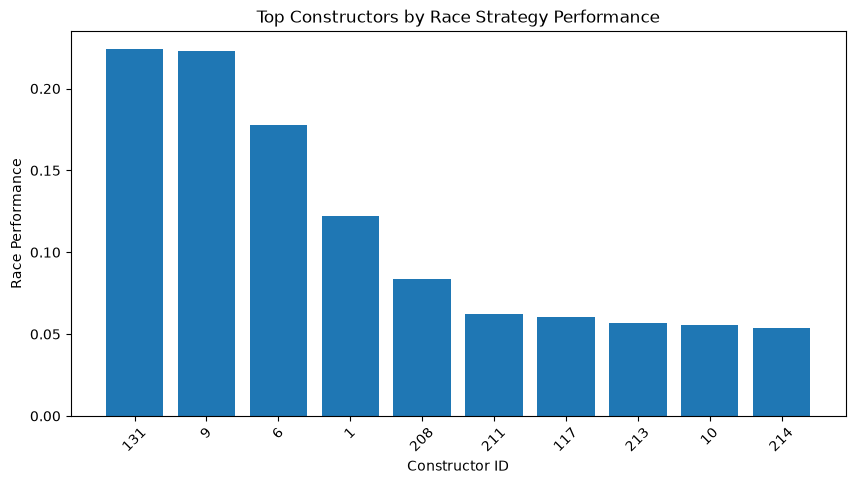

In [12]:
top_constructor_strategy = (
    constructor_strategy
    .head(10)
)

plt.figure(figsize=(10,5))

plt.bar(
    top_constructor_strategy.index.astype(str),
    top_constructor_strategy["race_performance"]
)

plt.xlabel("Constructor ID")
plt.ylabel("Race Performance")

plt.title(
    "Top Constructors by Race Strategy Performance"
)

plt.xticks(rotation=45)

plt.show()

### Step 11 — Create Strategy Classification Target

In [13]:
strategy_df["strategy_success"] = (
    strategy_df["podium"]
)

strategy_df["strategy_success"].value_counts()

strategy_success
0    6092
1    1017
Name: count, dtype: int64

### Step 12 — Select ML Features

In [14]:
features = [
    "year",
    "round",
    "driverId",
    "constructorId",
    "circuitId",
    "laps",
    "points",
    "positionOrder"
]


X = strategy_df[features]

y = strategy_df["strategy_success"]


print(X.shape)
print(y.shape)

(7109, 8)
(7109,)


### Step 13 — Save Strategy Dataset

### 

In [15]:
strategy_df.to_csv(
    "../../Dataset/f1_strategy_dataset.csv",
    index=False
)

print("Strategy dataset saved successfully!")

Strategy dataset saved successfully!


### Step 14 — Final Strategy Analysis Check

In [16]:
print(
    "F1 Strategy Prediction Dataset Created Successfully!"
)

print(
    "Total Strategy Records:",
    len(strategy_df)
)

F1 Strategy Prediction Dataset Created Successfully!
Total Strategy Records: 7109
